In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow keras transformers pillow opencv-python spotipy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 22.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import torch
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")

All imports successful


In [4]:
df = pd.read_csv('/content/dataset.xls')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

# from google.colab import drive
# # drive.mount('/content/drive')

# # Change this path to wherever your file is in Drive
# df = pd.read_excel('/content/dataset.xls')
# # df = pd.read_excel('/content/dataset.xls')

# print("Shape:", df.shape)
# print("Columns:", df.columns.tolist())
# df.head(3)

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [5]:
import os
print(os.listdir('/content'))

['.config', 'dataset.xls', 'sample_data']


Feature Selection & Scaling

In [6]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]

# Drop rows where any feature is missing
df = df.dropna(subset=features).reset_index(drop=True)

X_raw = df[features].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

input_dim = X_scaled.shape[1]
latent_dim = 3

print(f" Dataset ready: {X_scaled.shape[0]} songs, {input_dim} features")

 Dataset ready: 114000 songs, 9 features


Build Encoder

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 16   # 🔥 increased

# Encoder
inputs = layers.Input(shape=(9,))
x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

Build Decoder

In [19]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(9, activation="sigmoid")(x)

decoder = Model(latent_inputs, outputs, name="decoder")

VAE MODEL CLASS - CELL 7

In [20]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

        self.beta = 0.0   # 🔥 KL weight

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        # 🔥 Strong KL annealing
        self.beta = min(1.0, self.beta + 0.05)

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # ✅ FIXED reconstruction loss (scaled properly)
            recon_loss = tf.reduce_mean(
                tf.square(data - reconstruction)
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # ✅ Ensure KL is not ignored
            beta = tf.maximum(0.1, self.beta)

            total_loss = recon_loss + beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "beta": beta
        }

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

vae.fit(X_scaled, epochs=30, batch_size=64)

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - kl_loss: 9.6068e-06 - loss: 0.4648 - reconstruction_loss: 0.4648
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.0431e-06 - loss: 0.4403 - reconstruction_loss: 0.4403
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.2783e-07 - loss: 0.4229 - reconstruction_loss: 0.4229
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 2.9802e-07 - loss: 0.4098 - reconstruction_loss: 0.4098
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 1.1921e-07 - loss: 0.3892 - reconstruction_loss: 0.3892
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - kl_loss: 1.1921e-07 - loss: 0.5463 - reconstruction_loss: 0.5463
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.7881e-07 - loss: 0.4327 - reconstruction_loss: 0.4327
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: -2.9802e-08 - loss: 0.4221 - reconstruction_loss: 0.4221
Epoch 9/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s

Training VAE

Epoch 1/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0503
Epoch 2/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0492
Epoch 3/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 4/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0491
Epoch 5/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 6/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 7/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0491
Epoch 8/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 9/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 10/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0491
Epoch 11/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 12/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0491
Epoch 13/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0491
Epoch 14/30
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0491
Epoch 15/30
1782/1782 ━━━━━━

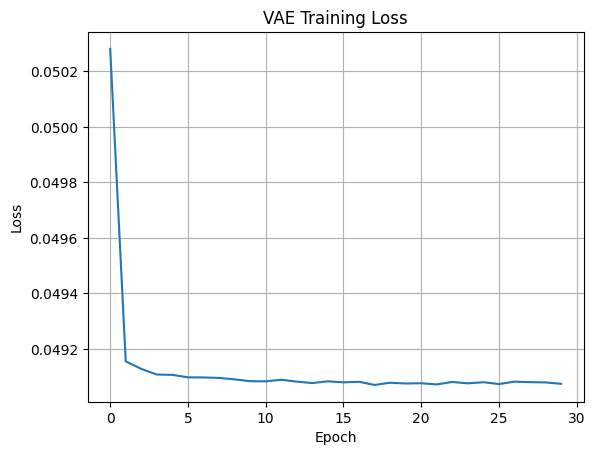

 VAE trained


In [13]:
z_means, _, _ = encoder.predict(X_scaled)

SAFER CHECKING CODE IF ALL VALUES ARE SAME EVEN NOW, RUNNNING BEFORE CELL 9

In [14]:
# Quick sanity check — z values should differ across songs
z_test, _, _ = encoder.predict(X_scaled[:5], verbose=0)
print(z_test)

[[-1.5003221e-05 -4.4907662e-07  2.6888611e-05]
 [-1.5003221e-05 -4.4907662e-07  2.6888611e-05]
 [-1.5003221e-05 -4.4907662e-07  2.6888611e-05]
 [-1.5003221e-05 -4.4907662e-07  2.6888611e-05]
 [-1.5003221e-05 -4.4907662e-07  2.6888611e-05]]


Encode all songs into latent space

In [15]:
z_means, _, _ = encoder.predict(X_scaled, verbose=0)

latent_df = pd.DataFrame(z_means, columns=["z1", "z2", "z3"])

df_final = pd.concat([
    df[["track_name", "artists", "track_genre", "valence", "energy", "acousticness"]].reset_index(drop=True),
    latent_df
], axis=1)

print("Latent space ready")
print(df_final.head(3))

Latent space ready
         track_name                 artists track_genre  valence  energy  \
0            Comedy             Gen Hoshino    acoustic    0.715   0.461   
1  Ghost - Acoustic            Ben Woodward    acoustic    0.267   0.166   
2    To Begin Again  Ingrid Michaelson;ZAYN    acoustic    0.120   0.359   

   acousticness        z1            z2        z3  
0        0.0322 -0.000015 -4.490766e-07  0.000027  
1        0.9240 -0.000015 -4.490766e-07  0.000027  
2        0.2100 -0.000015 -4.490766e-07  0.000027  


 Emotion → Latent Target + Recommendation

In [16]:
# Map each emotion to a target region in the VAE's learned feature space.
# These are heuristic centroids based on audio feature semantics:
#   HAPPY    = high valence + high energy
#   SAD      = low valence + low energy
#   ENERGETIC= high energy + low acousticness (angry/fear maps here)
#   CALM     = low energy + high acousticness
#   NEUTRAL  = mid everything

EMOTION_FEATURE_TARGETS = {
    "HAPPY":     np.array([0.8, 0.8, 0.2, 0.1, 0.1, 0.2, 0.3, 0.8, 0.7]),
    "SAD":       np.array([0.3, 0.2, 0.3, 0.1, 0.7, 0.3, 0.2, 0.2, 0.3]),
    "ENERGETIC": np.array([0.6, 0.9, 0.7, 0.2, 0.1, 0.1, 0.5, 0.5, 0.9]),
    "CALM":      np.array([0.4, 0.3, 0.3, 0.1, 0.8, 0.5, 0.2, 0.5, 0.3]),
    "NEUTRAL":   np.array([0.5, 0.5, 0.5, 0.2, 0.4, 0.2, 0.3, 0.5, 0.5]),
}

def recommend_songs(emotion_label, n=10):
    """
    1. Take emotion → build a target feature vector
    2. Pass through encoder → get target latent point
    3. Cosine similarity between target latent and all song latents
    4. Return top-n closest songs
    """
    if emotion_label not in EMOTION_FEATURE_TARGETS:
        print(f"Unknown emotion: {emotion_label}")
        return []

    # Scale the target vector the same way training data was scaled
    target_raw    = EMOTION_FEATURE_TARGETS[emotion_label].reshape(1, -1)
    target_scaled = scaler.transform(target_raw)

    # Encode to latent space
    target_z, _, _ = encoder.predict(target_scaled, verbose=0)

    # Cosine similarity against all song latents
    song_latents = df_final[["z1", "z2", "z3"]].values
    sims         = cosine_similarity(target_z, song_latents)[0]

    # Get top-n indices
    top_indices = np.argsort(sims)[::-1][:n]
    results     = df_final.iloc[top_indices][["track_name", "artists", "track_genre"]].copy()
    results["similarity"] = sims[top_indices].round(4)

    print(f"\n🎵 Top {n} songs for emotion: {emotion_label}\n")
    print(results.to_string(index=False))

    return results["track_name"].tolist()

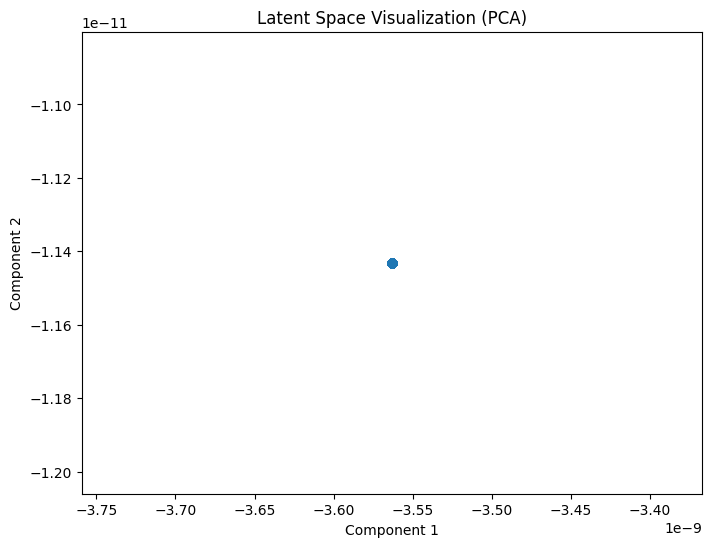

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Step 1: Reduce latent space to 2D
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_means)

# Step 2: Plot
plt.figure(figsize=(8,6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], alpha=0.5)

plt.title("Latent Space Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

Load ViT emotion model

In [ ]:
print("Loading ViT model... (first time may take ~1-2 min)")

vit_processor = ViTImageProcessor.from_pretrained("trpakov/vit-face-expression")
vit_model     = ViTForImageClassification.from_pretrained("trpakov/vit-face-expression")
vit_model.eval()

print("ViT model loaded")
print("Classes:", vit_model.config.id2label)

Loading ViT model... (first time may take ~1-2 min)


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/915 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT model loaded
Classes: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


ViT emotion prediction

In [ ]:
def predict_emotion_vit(image_input):
    """
    Accepts: PIL Image, numpy array (BGR from OpenCV), or file path string
    Returns: raw emotion string from ViT
    """
    if isinstance(image_input, str):
        img = Image.open(image_input).convert("RGB")
    elif isinstance(image_input, np.ndarray):
        img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
    elif isinstance(image_input, Image.Image):
        img = image_input.convert("RGB")
    else:
        raise ValueError("Unsupported image type")

    inputs  = vit_processor(images=img, return_tensors="pt")

    with torch.no_grad():
        outputs = vit_model(**inputs)

    predicted_class = outputs.logits.argmax(-1).item()
    label           = vit_model.config.id2label[predicted_class]

    return label

Emotion mapping from ViT to VAE

In [ ]:
# FER2013 has 7 classes: angry, disgust, fear, happy, neutral, sad, surprise
VIT_TO_VAE_MAP = {
    "happy":    "HAPPY",
    "surprise": "HAPPY",
    "sad":      "SAD",
    "angry":    "ENERGETIC",
    "fear":     "ENERGETIC",
    "disgust":  "ENERGETIC",
    "neutral":  "CALM",
}

def map_emotion(vit_label):
    return VIT_TO_VAE_MAP.get(vit_label.lower(), "NEUTRAL")

Full Pipeline

In [ ]:
def full_pipeline(image_input, n=10):
    """
    Input: image (PIL / numpy / path)
    Output: list of recommended song names
    """
    # Step 1: ViT detects emotion
    vit_emotion = predict_emotion_vit(image_input)
    print(f" ViT Detected Emotion : {vit_emotion}")

    # Step 2: Map to VAE emotion space
    mapped_emotion = map_emotion(vit_emotion)
    print(f" Mapped to VAE Label  : {mapped_emotion}")

    # Step 3: VAE recommends songs
    songs = recommend_songs(mapped_emotion, n=n)

    return songs

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import io

def capture_webcam():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      button.textContent = '📸 Capture';

      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    ''')

    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img = Image.open(io.BytesIO(binary)).convert('RGB')
    return img

📷 Allow camera → Click Capture


<IPython.core.display.Javascript object>

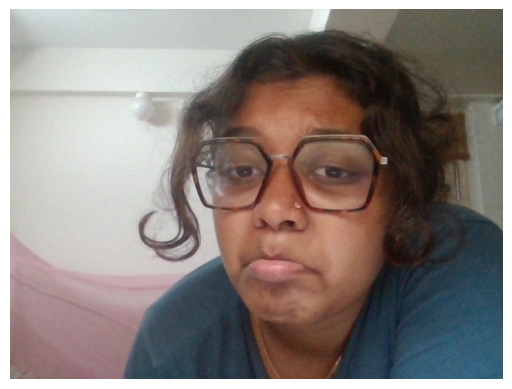

 ViT Detected Emotion : sad
 Mapped to VAE Label  : SAD

🎵 Top 10 songs for emotion: SAD

                 track_name          artists track_genre  similarity
                     Comedy      Gen Hoshino    acoustic         1.0
                  Barbincor    Cesária Evora world-music         1.0
                    Friends Michael W. Smith world-music         1.0
             Miss Perfumado    Cesária Evora world-music         1.0
           Water Into Light    Rainy Lullaby world-music         1.0
        Sleep My Little Boy    Rainy Lullaby world-music         1.0
   Frecuencia Álmica, Pt. 4   Lucas Cervetti world-music         1.0
How Can I Keep From Singing     Chris Tomlin world-music         1.0
      Your Love Never Fails    Jesus Culture world-music         1.0
At The Cross (Love Ran Red)     Chris Tomlin world-music         1.0


In [ ]:
from IPython.display import clear_output
clear_output()

print("📷 Allow camera → Click Capture")

img = capture_webcam()

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

songs = full_pipeline(img, n=10)

In [ ]:
from google.colab import files

print("Upload a face image (jpg/png):")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img      = Image.open(img_path)

# Show the image
plt.imshow(img)
plt.axis("off")
plt.title("Input Face")
plt.show()

# Run pipeline
songs = full_pipeline(img, n=10)

Upload a face image (jpg/png):


KeyboardInterrupt: 